In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys
import os

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")



from Utils import GridUtils as GrU






from Utils import utils as uti
from Utils import MyConstants as Co

#from Drivers import RegridField as RgF
import RegridField as RgF
import update_config as uc

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers

# Some other useful packages 
import importlib
from pathlib import Path

# Constants
grav=Co.grav()
cp=Co.cpair()
Rdry=Co.Rdry()
Rdair=Co.Rdair()

print( Rdry, Rdair )


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
287.05 287.0423113650487


In [2]:
year,month,day,hour=2016,8,15,0
date_=f"{year:04d}-{month:02d}-*"          #{day:02d}-{hour*3_600:05d}"
print( date_ )

#z,y=5,50

2016-08-*


In [3]:
%%time
"""
f=f'/glade/campaign/cgd/amp/juliob/mpasa3p75km/{date_}/Upwp_dyamond_ne16pg3_fv1x1.{date_}.nc'
Xmf = xr.open_mfdataset( f ,data_vars='different', coords='different', compat='no_conflicts' )

%%time

f=f'/glade/campaign/cgd/amp/juliob/mpasa3p75km/{date_}/DynVars_dyamond_fv1x1.{date_}.nc'
Xdy = xr.open_mfdataset( f ,data_vars='different', coords='different', compat='no_conflicts' )

%%time
"""

def keep_vars(ds):
    vars=['Upwp','Vpwp','rho_mpas',]
    return ds[vars]

f=f'/glade/campaign/cgd/amp/juliob/mpasa3p75km/{date_}/DynVars_dyamond_fv1x1.{date_}.nc'

f=f'/glade/derecho/scratch/juliob/archive/c124_dyamond1/atm/hist/DynVars_dyamond_fv1x1.{date_}.nc' 

Xmf = xr.open_mfdataset( f ,preprocess=keep_vars,data_vars='different', coords='different', compat='no_conflicts' )


f=f'/glade/campaign/cgd/amp/juliob/mpasa3p75km/TimeInvariant/zgrid_dyamond_fv1x1.nc'
Xzg = xr.open_dataset( f )


CPU times: user 4.82 s, sys: 1.4 s, total: 6.22 s
Wall time: 21.3 s


In [4]:
%%time
z,y=5,50

upwp=Xmf.Upwp.values
vpwp=Xmf.Vpwp.values





#            for z in np.arange( start=1,stop=nz ):
#                varpi[:,z,:] = 0.5*( varp[:,z-1,:] + varp[:,z,:] )
rho = Xmf.rho_mpas.values
zg  = Xzg.zgrid.values


CPU times: user 4.84 s, sys: 5.94 s, total: 10.8 s
Wall time: 30.2 s


In [ ]:
%%time
year,month=2004,8 #2004,7
date_tag = f"{year:04}-{month:02}-*"


f=f'/glade/derecho/scratch/juliob/archive/GW_UnitTest/xy-rdg-mm-frnt-00/xy-rdg-mm-frnt-00.h.{date_tag}.nc'
ncdata=f'/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.{date_tag}.nc' 


#print( f )
#X=xr.open_mfdataset( f ,data_vars='different', coords='different' , compat='no_conflicts' )
X14km=xr.open_mfdataset( ncdata ,data_vars='different', coords='different' , compat='no_conflicts' )

In [ ]:
X14km

In [ ]:

am=X14km.hyam.values
bm=X14km.hybm.values
ai=X14km.hyai.values
bi=X14km.hybi.values
ps=X14km.PS.values

RhoProxy = X14km.RhoProxy.values

In [ ]:
from Utils import MakePressures as MkP
importlib.reload(MkP)
pmid,pint,delp = MkP.Pressure ( am=am, bm=bm, ai=ai, bi=bi, ps=ps , p_00=100_000., Gridkey='tzyx' )

te14km = X14km.T.values

rho14km=pmid / (Rdair * te14km )

In [ ]:
rho14km.shape

In [ ]:
plt.plot( RhoProxy , zlev_14km )
plt.plot( rho14km[15,:,20,20], zlev_14km )

In [ ]:
%%time
upwp_14km = X14km.upwp.values
vpwp_14km = X14km.vpwp.values
epwp_14km = np.sqrt( upwp_14km**2 + vpwp_14km**2 )


plev_14km=X14km.lev.values
zlev_14km=-7_000. * np.log( plev_14km / 1_000. )

In [ ]:
print(np.shape(epwp_14km))

In [7]:
#plt.plot(rhoB[15,15,:])
epwp = np.sqrt( upwp**2 + vpwp**2 )
print( np.shape(upwp) )
nt,nz,ny,nx=np.shape(upwp)

(247, 59, 192, 288)


In [8]:
z,y,x=5,20,237
#z,y,x=5,40,20
lat,lon,ilev=Xmf.lat.values,Xmf.lon.values,Xmf.ilev.values
print( lon[x]-0*360. )
print( lat[y] )
print( ilev[z] )


296.25
-71.15183246073299
26003.5781


In [9]:
Lat = np.broadcast_to(lat[None, :, None], (nz, ny, nx))
Lon = np.broadcast_to(lon[None, None, :], (nz, ny, nx))


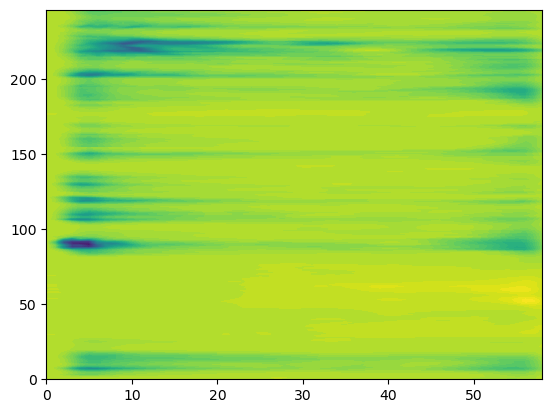

In [10]:
plt.contourf( upwp[:,:,y,x], levels=51 )
#plt.xlim(230,240)

In [11]:
zgF = np.flip( zg, axis=0 )

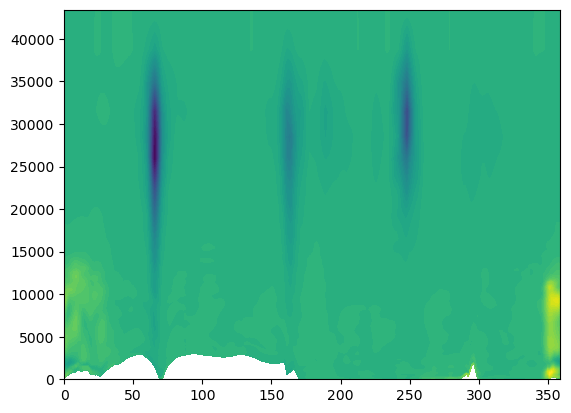

In [13]:
plt.contourf( Lon[:,y,:], zg[:,y,:]  , np.mean( upwp[38,:,y-2:y+2,:], axis=1), levels=51 )
#plt.xlim(230,240)

In [ ]:
#plt.contour( np.mean( upwp[:,5,:,:], axis=0 ) )
plt.contourf( upwp[40,5,:,:] ,levels=51 )


[43430.5469   38802.1914   34941.7031   31519.8965   28545.2402
 26003.5781   23860.8301   22068.9375   20573.0762   19318.2031
 18253.7637   17336.2344   16529.9336   15806.6387   15144.6123
 14527.4492   13942.9424   13382.1016   12838.3574   12306.9365
 11784.3818   11268.2002   10756.5947   10248.2744    9744.9043
  9244.9043    8744.90527   8244.90527   7744.90527   7244.90527
  6744.90527   6244.90576   5744.90576   5244.90527   4744.90527
  4244.90527   3764.00659   3332.39062   2956.11499   2625.70752
  2333.82471   2074.66064   1843.54736   1636.6781    1450.90918
  1283.61658   1132.58838    995.944763   872.075623   759.592834
   654.632812   556.409241   464.205017   377.351898   295.206604
   217.116669   142.359955    70.           0.      ]


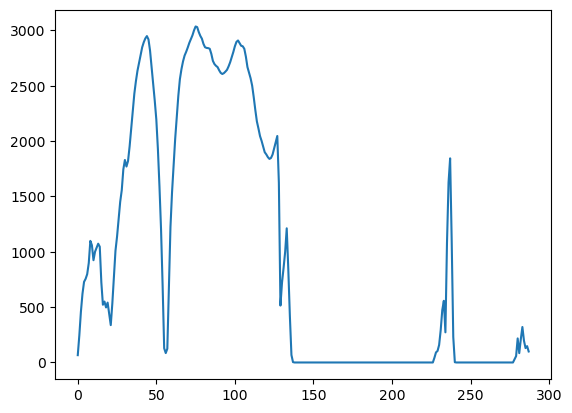

In [15]:

plt.plot( zg[58,y,:] )
print(ilev)

In [ ]:

import matplotlib.colors as mcolors


flev=0.01*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='gist_ncar'
#wavlev=15
wavlev_14km=26
case="UnitTest vs. ne240"
#title=f'{case}: {year:04}-{month:02}, Z={zlev[wavlev]/1000.:.0f} km '     #        camsnap-yaaaa.h.2004-06-15-21600.nc'
#print( zlev[wavlev] )
cmap = plt.cm.gist_ncar #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 2, figsize=(25,6) )
p=0
ax=axs[p]
c=ax.contourf(  np.mean( np.abs(upwp[:,5,:,:]), axis=0 ) , levels=flev, cmap=cmap, norm=norm, extend='both'  ) #levels=51)
to = ax.contour( zgF[58,:,:], levels=[1,100] ,colors='black')
ax.set_xlabel( "Longitude" )
ax.set_ylabel( "Latitude" )
#ax.set_title( "Frontal GW")
plt.colorbar(c)


In [ ]:

ftopo='/glade/work/juliob/Topo/NCARTopoJTB/cases/fv1x1_Sco100_GrnlAnt/output/fv1x1_gmted2010_modis_bedmachine_nc3000_Laplace0100_noleak_greenlndantarcsgh30fac2.50_20251009.nc'
Topo=xr.open_dataset( ftopo )

hs = Topo.PHIS.values/grav
sgh = Topo.SGH.values
sgh30 = Topo.SGH30.values

In [ ]:
import matplotlib.colors as mcolors


flev=0.01*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='gist_ncar'
#wavlev=15
wavlev_14km=26
case="UnitTest vs. ne240"
#title=f'{case}: {year:04}-{month:02}, Z={zlev[wavlev]/1000.:.0f} km '     #        camsnap-yaaaa.h.2004-06-15-21600.nc'
#print( zlev[wavlev] )
cmap = plt.cm.gist_ncar #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 2, figsize=(25,6) )
p=0
ax=axs[p]
c=ax.contourf( lon,lat, np.average( (rho_epwp) ,axis=0 ), levels=flev, cmap=cmap, norm=norm, extend='both'  ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_xlabel( "Longitude" )
ax.set_ylabel( "Latitude" )
#ax.set_title( "Frontal GW")
plt.colorbar(c)

p=1
ax=axs[p]
c=ax.contourf( lon,lat, (0.25)*np.average( (epwp_14km[:,wavlev_14km] ) ,axis=0 ), levels=flev, cmap=cmap, norm=norm, extend='both'  ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_xlabel( "Longitude" )
ax.set_ylabel( "Latitude" )
#ax.set_title( "Frontal GW")
plt.colorbar(c)





#plt.contourf( np.average( rhoupwp,axis=0 ), levels=51 )

In [ ]:
X14km

In [ ]:
rho_z = Xrho.rho_mpas.isel( time=50 ).values

In [ ]:
rho_z.shape

In [ ]:
plt.plot( rho_z[ :, 30, 200], Xrho.lev.values )

In [ ]:
#up=u-np.average(u,axis=3)
up2 = u - np.mean(u, axis=3, keepdims=True)


In [ ]:
plt.contourf(X.lon.values,X.lev.values,up[0,:,200,:]) 
plt.plot( X.lon,phis[200,:]/9.8, 'black' )
#plt.xlim(290,310)
plt.colorbar()

In [ ]:
plt.contourf(X.lon.values,X.lev.values,up2[0,:,200,:]) 
plt.plot( X.lon,phis[200,:]/9.8, 'black' )
#plt.xlim(290,310)
plt.colorbar()

In [ ]:
plt.contourf(X.lon.values,X.lev.values,u[0,:,200,:]) 
plt.plot( X.lon,phis[200,:]/9.8, 'black' )
#plt.xlim(290,310)
plt.colorbar()

In [ ]:
plt.contourf(X.lon.values,X.lev.values,th[0,:,200,:] , levels=np.linspace( 180, 1400, num=51 ) ) 
plt.plot( X.lon,phis[200,:]/9.8, 'black' )
#plt.xlim(290,310)
plt.colorbar()

In [ ]:
plt.contourf(X.lon.values,X.lev.values,te[0,:,200,:] , levels=np.linspace( 180, 300, num=51 ) ) 
plt.plot( X.lon,phis[200,:]/9.8, 'black' )
#plt.xlim(290,310)
plt.colorbar()

In [ ]:
z,y=9,200
print(X.lat.values[y],X.ilev.values[z])
fig,ax=plt.subplots( figsize=(20,10) )
c=ax.contourf(X.lon.values,X.lat.values,w[0,30,:,:],levels=np.linspace(2*(-39/2.)/19.5 ,2*(39/2.)/19.5, num=40) , cmap='bwr')
#plt.xlim(290,310)
#plt.ylim(-72,-60)
cbar = plt.colorbar(c)
cbar.set_ticks( np.linspace(-2,2,num=11) ) #[-2,-1,0,1,2] )

In [ ]:
upwp=X.Upwp.values
ilev=X.ilev.values


In [ ]:
print(ilev[10])

In [ ]:
plt.contourf( upwp[0,10,:,:] )
plt.colorbar()

In [ ]:
var=X['U'].values

In [ ]:
print( np.shape( var ) )

In [ ]:

####################################################################
# Results for 3.75 DYAMOND runs ...
# In /glade/campaign/cesm/km-scale/archive/
#
# cam77_dyamond1_prod1
# c124_dyamond1_prod2
#
# where the cam77 is the vanilla 'nodeep' run, and c124 is the 'clubb-mf' run.
#
# exmaple extraction :
#   ncks -O -v w_mpas,lat,lon c124_dyamond1_prod2.cam.h1i.2016-08-17-32400.nc /glade/derecho/scratch/juliob/w_mpas_dyamond.nc
# Adam's plll esmf ...
# /glade/campaign/cgd/amp/aherring/mpas-uniform/mpasa3p75/analysis/ESMF_parallel/ESMF_parallel.sh
#
# Making a background field (w_mpas for example)
# Regrid conseveatively from mpasa3p75km to ne16pg3:
#   ncremap -m /glade/work/juliob/HiRes_ana_dev/Drivers/mpasa3p75_TO_ne16pg3_cnsrv.nc w_mpas_dyamond.nc w_mpas_dyamond_ne16pg3.nc
# Then remap back (bilin) from ne16pg3 to mpasa3p75km to obtain the background on mpasa3p75km:
#   ncremap -m /glade/work/juliob/HiRes_ana_dev/Drivers/ne16pg3_TO_mpasa3p75_bilin.nc w_mpas_dyamond_ne16pg3.nc w_mpas_dyamond_ne16pg3_mpasa3p75.nc 

f='/glade/derecho/scratch/juliob/mpasa3p75km/U_dyamond.nc'
U=xr.open_dataset( f )
f='/glade/derecho/scratch/juliob/mpasa3p75km/U_dyamond_ne16pg3_mpasa3p75.nc'
Ubk=xr.open_dataset( f )
f='/glade/derecho/scratch/juliob/mpasa3p75km/w_mpas_dyamond.nc'
W=xr.open_dataset( f )
f='/glade/derecho/scratch/juliob/mpasa3p75km/w_mpas_dyamond_ne16pg3_mpasa3p75.nc'
Wbk=xr.open_dataset( f )





In [ ]:
%%time

lon=U.lon.values
lat=U.lat.values
u=U.U.values
ubk=Ubk.U.values
w=W.w_mpas.values
wbk=Wbk.w_mpas.values


In [ ]:
U

In [ ]:
print(U.lev.values[10])

In [ ]:
up=u-ubk
wp=w-wbk

In [ ]:
import matplotlib.pyplot as plt

plt.scatter( lon[0:100_000] , lat[0:100_000] )



#plt.tricontourf( lon,lat,up[0,20,:] )

In [ ]:
yoo=np.where( (lat<-40.)&(lat >-70.)&(lon>250.) )

In [ ]:
upwp=up*wp[:,1:,:]

In [ ]:
wlev=np.linspace( -2,2, num=51 )

plt.tricontourf( lon[yoo[0][:]] , lat[yoo[0][:]] , upwp[0,10, yoo[0][:] ] , levels=wlev, cmap='bwr'  )

plt.colorbar()

In [ ]:
coords = dict( 
    time = ( ["time"],  U.time.values ),
    lev  = ( ["lev"],U.lev.values),
    ilev = ( ["ilev"],U.ilev.values),
)


Xout = xr.Dataset( coords=coords  )

dims = ('ncol' )
Dar = xr.DataArray( data=U.lon.values , 
                    dims=dims,)
Xout[ 'lon' ]= Dar

dims = ('ncol' )
Dar = xr.DataArray( data=U.lat.values , 
                    dims=dims,)
Xout[ 'lat' ]= Dar



new_attributes = {
    'units': 'm+2 s-2',
    'long_name': 'flux up x wp',}

dims = ('time','lev','ncol' )
Dar = xr.DataArray( data=upwp , 
                    dims=dims,
                    attrs=new_attributes ,) 
                        
Xout[ 'upwp' ]= Dar
f='/glade/derecho/scratch/juliob/mpasa3p75km/UpWp_dyamond.nc'

Xout.to_netcdf( f )


In [ ]:
%%time

#####################################
# Initialize regrid-object library
RgObLib={}


RgOb_ne240_x_ne16   = GrU.regrid_object_lib(RgOb=RgObLib, src='mpasa3_75',dst='ne240pg3',  RegridMethod='BILINEAR'   ) #'CONSERVE_2ND')


In [ ]:
import subprocess

infile = "c124_dyamond1_prod2.cam.h1i.2016-08-17-32400.nc"
tmp1   = "/glade/derecho/scratch/juliob/w_mpas_dyamond.nc"
tmp2   = "w_mpas_dyamond_ne16pg3.nc"
outfile= "w_mpas_dyamond_ne16pg3_mpasa3p75.nc"

cmds = [
    # extract variable
    f"ncks -O -v w_mpas,lat,lon {infile} {tmp1}",

    # conservative remap mpasa3p75km -> ne16pg3
    "ncremap -m /glade/work/juliob/HiRes_ana_dev/Drivers/mpasa3p75_TO_ne16pg3_cnsrv.nc "
    f"{tmp1} {tmp2}",

    # bilinear remap ne16pg3 -> mpasa3p75km
    "ncremap -m /glade/work/juliob/HiRes_ana_dev/Drivers/ne16pg3_TO_mpasa3p75_bilin.nc "
    f"{tmp2} {outfile}",
]

for c in cmds:
    print("Running:", c)
    result = subprocess.run(c, shell=True)

    if result.returncode != 0:
        raise RuntimeError(f"Command failed: {c}")

print("All done.")


In [ ]:
import subprocess

subprocess.run(
    ["ncks", "-O", "-v", "w_mpas,lat,lon",
     "c124_dyamond1_prod2.cam.h1i.2016-08-17-32400.nc",
     "/glade/derecho/scratch/juliob/w_mpas_dyamond.nc"],
    check=True
)

subprocess.run(
    ["ncremap", "-m", "/glade/work/juliob/HiRes_ana_dev/Drivers/mpasa3p75_TO_ne16pg3_cnsrv.nc",
     "w_mpas_dyamond.nc",
     "w_mpas_dyamond_ne16pg3.nc"],
    check=True
)

subprocess.run(
    ["ncremap", "-m", "/glade/work/juliob/HiRes_ana_dev/Drivers/ne16pg3_TO_mpasa3p75_bilin.nc",
     "w_mpas_dyamond_ne16pg3.nc",
     "w_mpas_dyamond_ne16pg3_mpasa3p75.nc"],
    check=True
)

print("All done.")
